In [88]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns

df = pd.read_csv('./data/train.csv')

df = df.iloc[0:10000]

df.head(10)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0
5,5,24,male,b.com,5.04,85.1,yes,9.4,average,online videos,medium,moderate,70.1
6,6,20,male,b.sc,4.28,87.0,no,9.1,average,mixed,high,moderate,63.4
7,7,22,female,ba,4.19,44.9,yes,8.8,good,self-study,high,hard,76.8
8,8,22,other,b.com,1.06,98.3,yes,5.0,poor,mixed,low,moderate,46.7
9,9,18,male,bba,3.44,80.9,yes,6.2,good,group study,medium,easy,58.2


(array([3217.,    0.,    0.,    0.,    0., 3444.,    0.,    0.,    0.,
        3339.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

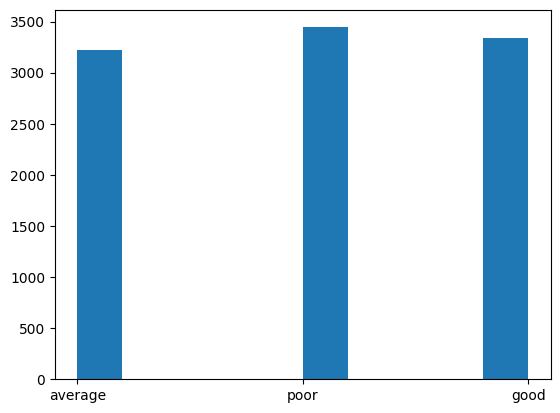

In [114]:
plt.hist(df['sleep_quality'])

In [94]:
def sleep_coefficient(x):
    if x == 'poor':
        return 0.75
    elif x == 'average':
        return 1.0
    elif x == 'good':
        return 1.25
    else:
        return np.nan
    
df['sleep_coefficient'] = df['sleep_quality'].apply(sleep_coefficient)
df['sleep_quality_coef'] = df['sleep_coefficient']*df['sleep_hours']

<Axes: >

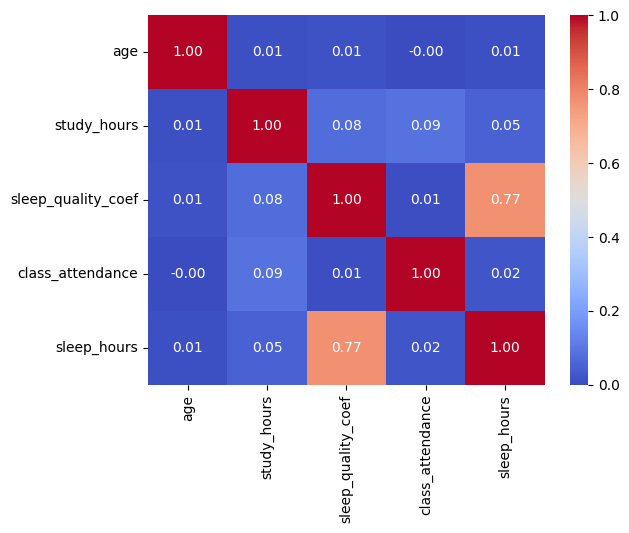

In [95]:
sns.heatmap(df[['age', 'study_hours', 'sleep_quality_coef', 'class_attendance', 'sleep_hours']].corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [96]:
label_encoder_facility = LabelEncoder()
label_study_method = LabelEncoder()
label_facility = LabelEncoder()
label_course = LabelEncoder()
gender = LabelEncoder()


df['Labeled_facility'] = label_facility.fit_transform(df['facility_rating'])
df['Labeled_exam_difficulty'] = label_encoder_facility.fit_transform(df['exam_difficulty'])
df['Labeled_study_method'] = label_study_method.fit_transform(df['study_method'])
df['Labeled_course'] = label_course.fit_transform(df['course'])
df['Labeled_gender'] = gender.fit_transform(df['gender'])

In [97]:
one_hot_encoder_facility = OneHotEncoder()

one_hot_encoded_facility = one_hot_encoder_facility.fit_transform(df[['facility_rating']])

In [44]:
df[['facility_rating']]

,facility_rating
0,low
1,medium
2,high
3,high
4,high
...,...
9995,medium
9996,low
9997,low
9998,medium


In [98]:
df_facility_rating = pd.DataFrame(one_hot_encoded_facility.toarray(), columns=one_hot_encoder_facility.get_feature_names_out())

df = pd.merge(df, df_facility_rating, left_index=True, right_index=True)

In [50]:
df

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,facility_rating_high,facility_rating_low,facility_rating_medium
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3,0.0,1.0,0.0
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7,0.0,0.0,1.0
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0,1.0,0.0,0.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9,1.0,0.0,0.0
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,17,other,b.sc,5.22,67.1,yes,6.5,average,online videos,medium,moderate,43.1,0.0,0.0,1.0
9996,9996,24,male,bba,4.21,50.7,yes,7.1,average,mixed,low,moderate,73.5,0.0,1.0,0.0
9997,9997,23,female,bca,5.75,93.0,yes,8.2,average,coaching,low,moderate,72.7,0.0,1.0,0.0
9998,9998,17,female,b.sc,1.73,73.8,yes,7.3,good,coaching,medium,hard,71.3,0.0,0.0,1.0


In [22]:
one_hot_encoder_facility.get_feature_names_out()

array(['facility_rating_high', 'facility_rating_low',
       'facility_rating_medium'], dtype=object)

In [9]:
df['facility_rating']

0          low
1       medium
2         high
3         high
4         high
         ...  
9995    medium
9996       low
9997       low
9998    medium
9999    medium
Name: facility_rating, Length: 10000, dtype: object

In [11]:
label_study_method.inverse_transform(df['Labeled_facility'])

array(['group study', 'mixed', 'coaching', ..., 'group study', 'mixed',
       'mixed'], shape=(10000,), dtype=object)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(df[['study_hours', 'sleep_hours', 'sleep_quality_coef', 'class_attendance', 'facility_rating_high', 'facility_rating_low', 'facility_rating_medium', 'age']], df['exam_score'])

model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [116]:
print(model.feature_names_in_, model.feature_importances_)


['study_hours' 'sleep_hours' 'sleep_quality_coef' 'class_attendance'
 'facility_rating_high' 'facility_rating_low' 'facility_rating_medium'
 'age'] [0.644884   0.04350281 0.09883503 0.15262122 0.01106272 0.01594787
 0.00402923 0.02911713]


In [117]:
model = GradientBoostingRegressor()

model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [118]:
print(r2_score(y_test, model.predict(X_test)),
    mean_absolute_error(y_test, model.predict(X_test)),
    mean_squared_error(y_test, model.predict(X_test)))

0.7480113200302889 7.72589080135321 93.68353465738926


In [110]:
model_baseline = LinearRegression()

model_baseline.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [111]:
print(r2_score(y_test, model_baseline.predict(X_test)),
    mean_absolute_error(y_test, model_baseline.predict(X_test)),
    mean_squared_error(y_test, model_baseline.predict(X_test)))

0.7506154228706615 7.482206830621802 88.67460744439303


In [26]:
X_train, X_test, y_train, y_test = train_test_split(df[['study_hours', 'sleep_hours', 'class_attendance', 'Labeled_exam_difficulty', 'Labeled_study_method']], df['exam_score'])


In [112]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor()

model_cat.fit(X_train, y_train)

Learning rate set to 0.056291
0:	learn: 18.4954410	total: 2.17ms	remaining: 2.17s
1:	learn: 17.8434006	total: 4.03ms	remaining: 2.01s
2:	learn: 17.2507750	total: 5.89ms	remaining: 1.96s
3:	learn: 16.6707945	total: 7.8ms	remaining: 1.94s
4:	learn: 16.1406881	total: 9.67ms	remaining: 1.92s
5:	learn: 15.6561899	total: 11.6ms	remaining: 1.93s
6:	learn: 15.2041549	total: 13.4ms	remaining: 1.91s
7:	learn: 14.7790854	total: 15.3ms	remaining: 1.9s
8:	learn: 14.3944340	total: 17.1ms	remaining: 1.88s
9:	learn: 14.0309291	total: 18.9ms	remaining: 1.87s
10:	learn: 13.6835151	total: 20.8ms	remaining: 1.87s
11:	learn: 13.3858569	total: 22.7ms	remaining: 1.87s
12:	learn: 13.0893630	total: 24.5ms	remaining: 1.86s
13:	learn: 12.8286378	total: 26.5ms	remaining: 1.86s
14:	learn: 12.5891698	total: 28.4ms	remaining: 1.86s
15:	learn: 12.3572201	total: 30.2ms	remaining: 1.86s
16:	learn: 12.1564138	total: 32.2ms	remaining: 1.86s
17:	learn: 11.9572232	total: 34.1ms	remaining: 1.86s
18:	learn: 11.7829524	total:

CatBoostRegressor(loss_function='RMSE')

In [113]:
print(r2_score(y_test, model_cat.predict(X_test)),
    mean_absolute_error(y_test, model_cat.predict(X_test)),
    mean_squared_error(y_test, model_cat.predict(X_test)))

0.7395129852381916 7.639187189665836 92.62234274570051


In [22]:
model_best_gbm = GridSearchCV(
    estimator=model,
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'max_leaf_nodes': [None, 10, 20],
    },
)

model_best_gbm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [23]:
print(r2_score(y_test, model_best_gbm.predict(X_test)),
    mean_absolute_error(y_test, model_best_gbm.predict(X_test)),
    mean_squared_error(y_test, model_best_gbm.predict(X_test)))

0.710368113751993 8.310644200932206 106.88682386546903
